# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

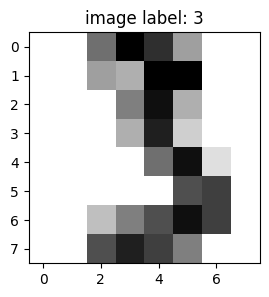

In [21]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [22]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [39]:
def one_hot(n_classes, y):
    y = np.array(y).reshape(-1).astype(int)
    return np.eye(n_classes)[y]


In [40]:
one_hot(n_classes=10, y=3)

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

In [41]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [42]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [43]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [44]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [45]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [46]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [47]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [48]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [49]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [50]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [57]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        self.W = np.random.uniform(size=(input_size, output_size), high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size, high=0.1, low=-0.1)
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Compute the linear combination of the input and weights
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:                      # allow single sample
            X = X[None, :]
        Z = X @ self.W + self.b              # (N, C)
        return softmax(Z)                    # use your earlier softmax

    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        P = self.forward(X)
        P = np.clip(P, 1e-12, 1.0)
        return -np.mean(np.sum(y * np.log(P), axis=1))


    def grad_loss(self, X, y_true, y_pred):
        grad_W = np.dot(X.T, (y_pred - y_true))
        grad_b = np.sum(y_pred - y_true, axis=0)
        return grad_W, grad_b
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
#model = LogisticRegression(input_size=64, output_size=10)
#try:
    #assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
   # assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
#except:
    #raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [58]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

In [59]:
# inside LogisticRegression
def forward(self, X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X[None, :]
    logits = X @ self.W + self.b
    return softmax(logits)

def predict(self, X):
    probs = self.forward(X)
    return np.argmax(probs, axis=1)

def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx])

    x = np.arange(len(classes))
    y_true = one_hot(len(classes), int(y_test[sample_idx])).ravel()
    y_pred = model.forward(X_test[sample_idx:sample_idx+1]).ravel()

    ax1.bar(x - 0.2, y_true, width=0.4, label='true')
    ax1.bar(x + 0.2, y_pred, width=0.4, label='prediction', color="red")
    ax1.set_xticks(x)
    prediction = np.argmax(y_pred)
    ax1.set_title('Output probabilities (prediction: %d)' % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()


Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [60]:
# training cell
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)
learning_rate = 0.01

for i in range(len(X_train)):
    x = X_train[i:i+1]
    y = y_train[i:i+1]
    y_pred = lr.forward(x)
    y_true = one_hot(lr.output_size, np.array(y).reshape(-1).astype(int))
    grad_W, grad_b = lr.grad_loss(x, y_true, y_pred)
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    if i > 0 and i % 100 == 0:
        y_batch = np.array(y_train[max(0, i-100):i]).reshape(-1).astype(int)
        y_true_batch = one_hot(lr.output_size, y_batch)
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_true_batch)
        print("Average NLL over last 100 samples at step %d: %.6f" % (i, avg_nll))


Average NLL over last 100 samples at step 100: 3.050978
Average NLL over last 100 samples at step 200: 1.231735
Average NLL over last 100 samples at step 300: 0.909451
Average NLL over last 100 samples at step 400: 1.668503
Average NLL over last 100 samples at step 500: 2.063034
Average NLL over last 100 samples at step 600: 1.129463
Average NLL over last 100 samples at step 700: 1.469685
Average NLL over last 100 samples at step 800: 1.543452
Average NLL over last 100 samples at step 900: 0.638065
Average NLL over last 100 samples at step 1000: 1.714245
Average NLL over last 100 samples at step 1100: 1.087034
Average NLL over last 100 samples at step 1200: 1.931820
Average NLL over last 100 samples at step 1300: 2.764527
Average NLL over last 100 samples at step 1400: 0.474432
Average NLL over last 100 samples at step 1500: 0.693182


Evaluate the trained model on the first example:

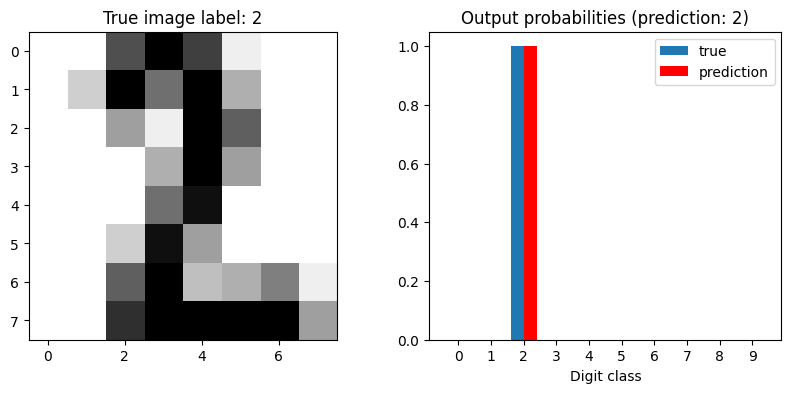

In [61]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

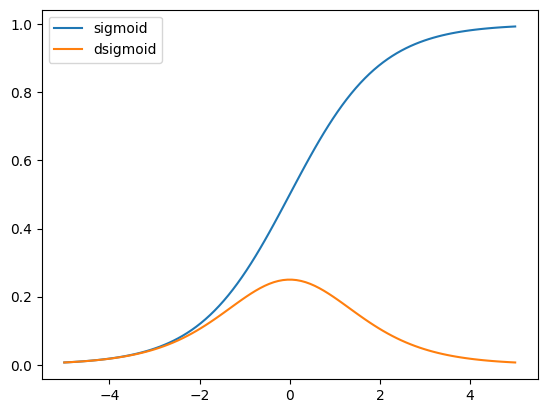

In [63]:
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500)
    return 1 / (1 + np.exp(-X))

def dsigmoid(X):
    s = sigmoid(X)
    return s * (1 - s)



x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [65]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = np.dot(X, self.W_h) + self.b_h
        # Apply the sigmoid activation function
        return sigmoid(self.Z_h)

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H, self.W_o) + self.b_o
        # Apply the softmax activation function (output)
        return softmax(self.Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)
        return Y

    def loss(self, X, y):
        Ypred = self.forward(X)
        Ypred = np.clip(Ypred, 1e-15, 1)
        y = one_hot(self.output_size, y)
        return -np.mean(np.sum(y * np.log(Ypred), axis=1))

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)
        error_o = y_pred - y_true
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)
        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)

        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)


Once the code is written, we can test our model on a single sample:

In [66]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [67]:
model.loss(X_train, y_train)

np.float64(2.323248505810956)

In [68]:
model.accuracy(X_train, y_train)

np.float64(0.12180746561886051)

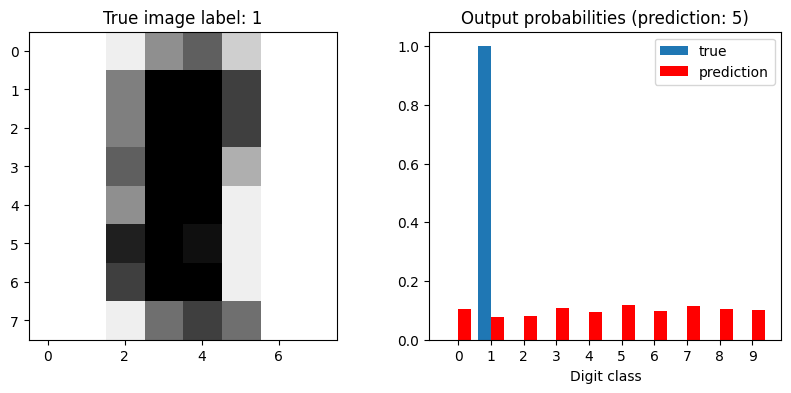

In [69]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [70]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 2.32325, train acc: 0.122, test acc: 0.137
Epoch #1, train loss: 1.76927, train acc: 0.484, test acc: 0.496
Epoch #2, train loss: 1.18071, train acc: 0.806, test acc: 0.770
Epoch #3, train loss: 0.78814, train acc: 0.873, test acc: 0.822
Epoch #4, train loss: 0.56536, train acc: 0.908, test acc: 0.881
Epoch #5, train loss: 0.42781, train acc: 0.932, test acc: 0.919
Epoch #6, train loss: 0.33944, train acc: 0.950, test acc: 0.930
Epoch #7, train loss: 0.28243, train acc: 0.963, test acc: 0.941
Epoch #8, train loss: 0.24526, train acc: 0.968, test acc: 0.937
Epoch #9, train loss: 0.21850, train acc: 0.970, test acc: 0.937
Epoch #10, train loss: 0.19795, train acc: 0.971, test acc: 0.941
Epoch #11, train loss: 0.18116, train acc: 0.971, test acc: 0.948
Epoch #12, train loss: 0.16619, train acc: 0.974, test acc: 0.956
Epoch #13, train loss: 0.15176, train acc: 0.977, test acc: 0.959
Epoch #14, train loss: 0.13906, train acc: 0.978, test acc: 0.959
Epoch #15, train 

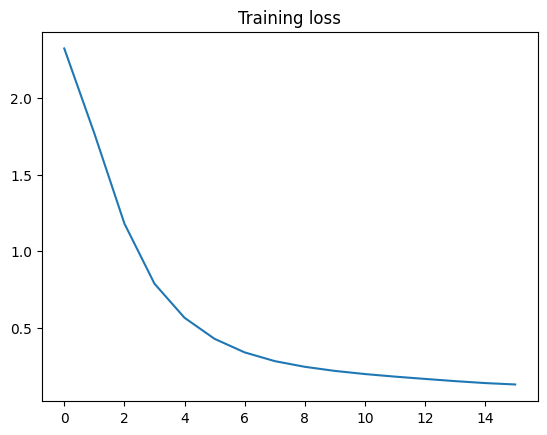

In [71]:
plt.plot(losses)
plt.title("Training loss");

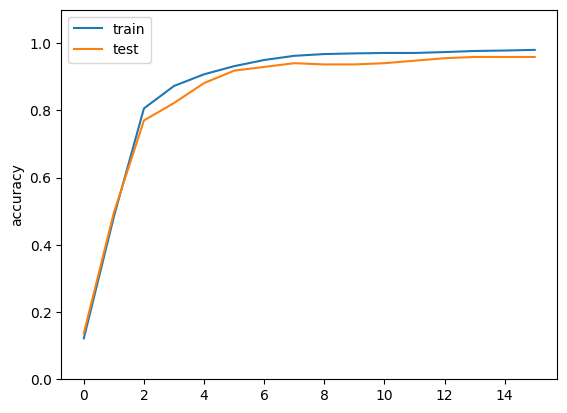

In [72]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

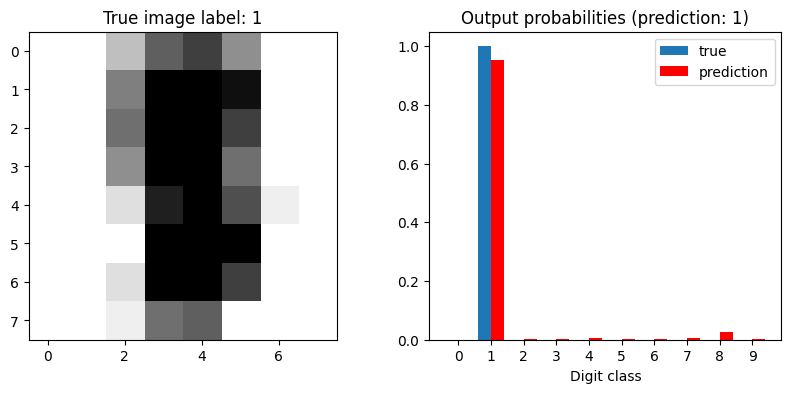

In [73]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

True label: 5, Predicted: 3
True label: 4, Predicted: 1
True label: 8, Predicted: 3
True label: 4, Predicted: 1
True label: 5, Predicted: 9


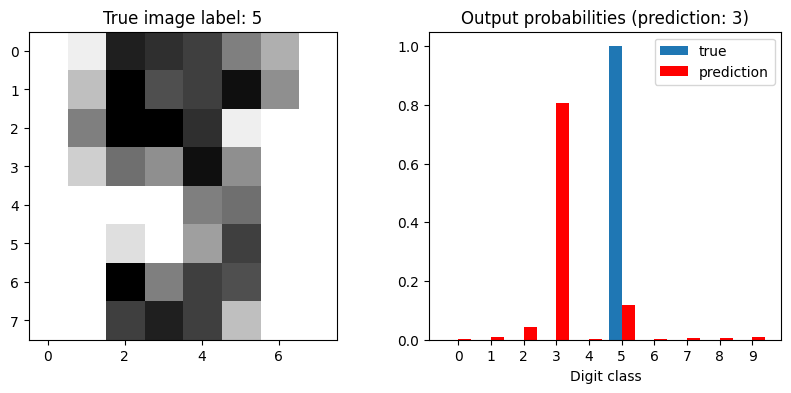

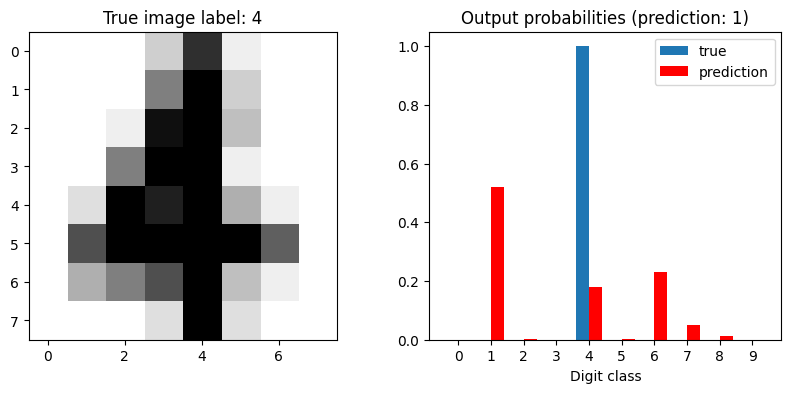

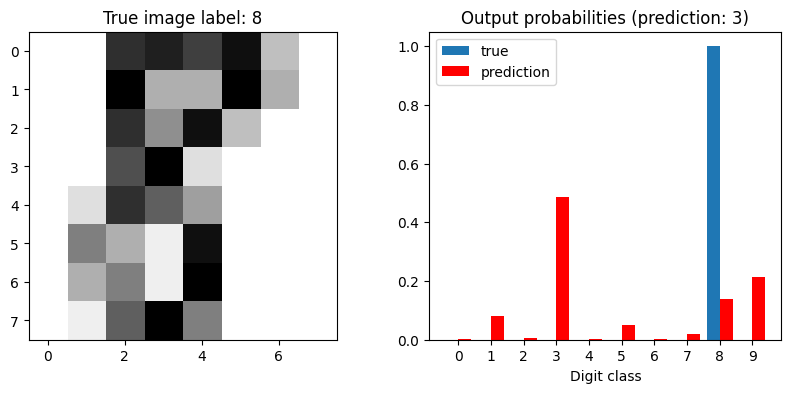

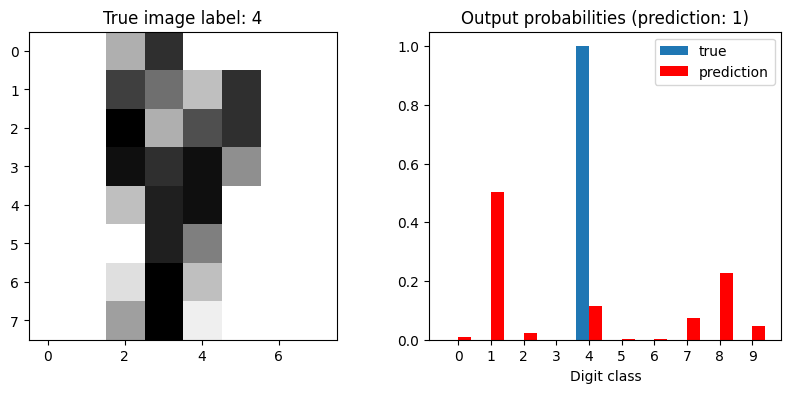

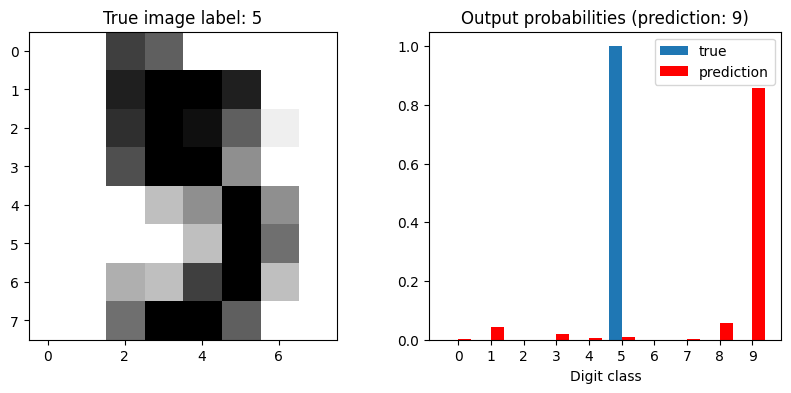

In [75]:
# Your code here
# Find test set predictions
y_pred = model.predict(X_test)
# If your `predict` outputs class labels, this is enough. If it outputs probabilities, use np.argmax(..., axis=1)
# Get indices where prediction is incorrect
wrong_idxs = np.where(y_pred != y_test)[0]

# Find the indices with the largest difference between max predicted probability and target (optional: 'confidence' error)
y_probs = model.forward(X_test)
true_class_probs = y_probs[np.arange(len(y_probs)), y_test]
confidence = y_probs.max(axis=1)
worst_idxs = np.argsort(true_class_probs)[:5]  # 5 least-confident correct class predictions
# Or top N largest negative margin (if you want "most confident wrong predictions")
worst_errors = np.argsort(confidence[wrong_idxs])[-5:]  # high-confidence mistakes

# Visualize a few worst predictions
for idx in wrong_idxs[:5]:  # or for idx in worst_idxs:
    plot_prediction(model, sample_idx=idx)
    print(f"True label: {y_test[idx]}, Predicted: {y_pred[idx]}")


### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [ ]:
# Your code here

In [76]:
# Example: grid search over learning rate and hidden size
learning_rates = [0.001, 0.01, 0.1]
hidden_sizes = [16, 32, 64, 128]

best_acc = 0
best_params = {}
for lr in learning_rates:
    for hs in hidden_sizes:
        nn = NeuralNet(input_size=X_train.shape[1], hidden_size=hs, output_size=10)
        for epoch in range(15):
            for x_sample, y_label in zip(X_train, y_train):
                nn.train(x_sample, y_label, lr)
        acc = nn.accuracy(X_test, y_test)
        print(f"Learning rate: {lr}, Hidden size: {hs}, Test accuracy: {acc:.3f}")
        if acc > best_acc:
            best_acc = acc
            best_params = {'lr': lr, 'hidden_size': hs}

print(f"Best parameters: {best_params}, Best test accuracy: {best_acc:.3f}")


Learning rate: 0.001, Hidden size: 16, Test accuracy: 0.541
Learning rate: 0.001, Hidden size: 32, Test accuracy: 0.963
Learning rate: 0.001, Hidden size: 64, Test accuracy: 0.970
Learning rate: 0.001, Hidden size: 128, Test accuracy: 0.978
Learning rate: 0.01, Hidden size: 16, Test accuracy: 0.107
Learning rate: 0.01, Hidden size: 32, Test accuracy: 0.107
Learning rate: 0.01, Hidden size: 64, Test accuracy: 0.107
Learning rate: 0.01, Hidden size: 128, Test accuracy: 0.789
Learning rate: 0.1, Hidden size: 16, Test accuracy: 0.107
Learning rate: 0.1, Hidden size: 32, Test accuracy: 0.107
Learning rate: 0.1, Hidden size: 64, Test accuracy: 0.107
Learning rate: 0.1, Hidden size: 128, Test accuracy: 0.107
Best parameters: {'lr': 0.001, 'hidden_size': 128}, Best test accuracy: 0.978
